# 03 · Arranque del bloque de aprendizaje profundo

Este notebook es para Cesar. Conviene haber pasado antes por `01_primeros_pasos`, porque el autoencoder es, conceptualmente, el primo no lineal del SPE que allí se calcula con PCA. Entender esa relación es lo que después da juego en la discusión conjunta del capítulo 6.

Para que corra en cualquier sitio sin instalar PyTorch, el autoencoder de aquí es un **MLP de scikit-learn entrenado para reconstruir su propia entrada**. La idea es idéntica a la de una red profunda y el flujo de evaluación es exactamente el que hay que seguir después con PyTorch; lo único que cambia es la librería con la que se construye la red.

Lo importante de este notebook no es la red. Es la sección 5, que muestra con números la trampa en la que cae buena parte de la literatura de *deep learning* sobre el TEP.

In [1]:
import os
from pathlib import Path
if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tfmfdd import data, metrics, plots, limits
from tfmfdd.preprocessing import Scaler
from tfmfdd.pca import PCAMonitor
from sklearn.neural_network import MLPRegressor

plots.use_style()
onset = data.FAULT_ONSET_TEST   # 160

## 1. La idea del autoencoder

Se entrena una red para que reproduzca su entrada pasando por un cuello de botella: 52 variables entran, se comprimen a unas pocas, y se descomprimen otra vez a 52. Si se entrena **solo con operación normal**, la red aprende a reconstruir bien lo normal y mal lo que no lo es.

El **error de reconstrucción** —la distancia entre lo que entró y lo que salió— es entonces un indicador de anomalía. Es exactamente el papel del SPE en el PCA: allí el residuo respecto al subespacio lineal, aquí el residuo respecto a una función no lineal aprendida.

Igual que el PCA, aquí también se reservan datos normales para calibrar el umbral. Más abajo se ve por qué.

In [2]:
normal = data.values(data.load_classic(0, "train"))
corte = int(len(normal) * 0.7)
X_fit, X_cal = normal[:corte], normal[corte:]

escalador = Scaler().fit(X_fit)          # preprocessing.py: solo con datos de ajuste
Z_fit, Z_cal = escalador.transform(X_fit), escalador.transform(X_cal)

# Autoencoder: 52 -> 16 -> 52. La salida es la propia entrada.
ae = MLPRegressor(hidden_layer_sizes=(16,), activation="tanh", max_iter=2000,
                  random_state=0, tol=1e-6)
ae.fit(Z_fit, Z_fit)

def error_reconstruccion(modelo, Z):
    return np.sum((Z - modelo.predict(Z)) ** 2, axis=1)

print("Error medio en ajuste     :", error_reconstruccion(ae, Z_fit).mean().round(3))
print("Error medio en calibración:", error_reconstruccion(ae, Z_cal).mean().round(3), " <- más alto, y eso es lo esperado")

Error medio en ajuste     : 17.619
Error medio en calibración: 23.309  <- más alto, y eso es lo esperado


Ese segundo número es la clave de todo el bloque. El error sobre los datos de calibración es mayor que sobre los del ajuste **aunque los dos sean operación normal**, porque la red se ajustó minimizando el error precisamente sobre los primeros. Si el umbral se calibra con el error del ajuste, sale demasiado bajo.

## 2. Calibrar el umbral → `limits.py`

Se usa la misma función que el PCA para su SPE: `limit_empirical` toma el percentil 99 del error sobre los datos **reservados**. Así los umbrales del autoencoder y del PCA salen del mismo procedimiento y son comparables.

In [3]:
umbral = limits.limit_empirical(error_reconstruccion(ae, Z_cal), alpha=0.99)
print(f"Umbral del error de reconstrucción (99 %, con reserva): {umbral:.2f}")

Umbral del error de reconstrucción (99 %, con reserva): 41.31


## 3. Detectar un fallo

Mismo flujo que con el PCA: se calcula el estadístico sobre la simulación completa, se dibuja la carta de control con `plots.control_chart`, y se mide con `metrics.evaluate_run`. Fallo 1 para empezar, que es de los fáciles.

far              0.019
fdr              0.998
delay_samples        2
delay_minutes      6.0
detected             1
dtype: object

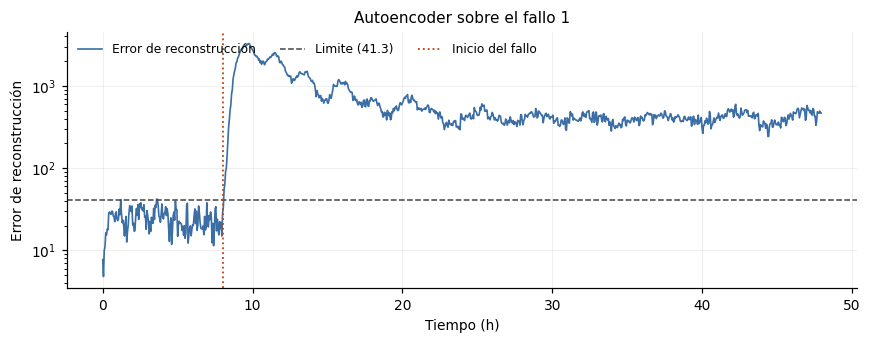

In [4]:
prueba = data.load_classic(1, "test")
err = error_reconstruccion(ae, escalador.transform(data.values(prueba)))

fig, ax = plt.subplots(figsize=(8, 3.2))
plots.control_chart(err, umbral, onset=onset, ylabel="Error de reconstrucción", ax=ax)
ax.set_title("Autoencoder sobre el fallo 1")
plt.tight_layout()

pd.Series(metrics.evaluate_run(err, umbral, onset=onset)).round(3)

## 4. Los 21 fallos, comparados con el PCA

Ahora los dos detectores sobre los mismos ficheros, con los mismos datos de ajuste y de calibración y la misma confianza. Es la comparación que después se hace sobre Rieth con cientos de simulaciones e intervalos de confianza; aquí es una sola simulación por fallo, así que los números son orientativos.

far                 fdr         delay_samples        
method      Autoencoder PCA-SPE Autoencoder PCA-SPE   Autoencoder PCA-SPE
faultNumber                                                              
0                 0.021   0.028         NaN     NaN           NaN     NaN
1                 0.019   0.025       0.998   0.998           2.0     2.0
3                 0.081   0.125       0.045   0.038          87.0   537.0
9                 0.025   0.044       0.042   0.058           5.0   223.0
15                0.019   0.031       0.091   0.084         577.0    92.0
6                 0.000   0.012       1.000   1.000           0.0     0.0

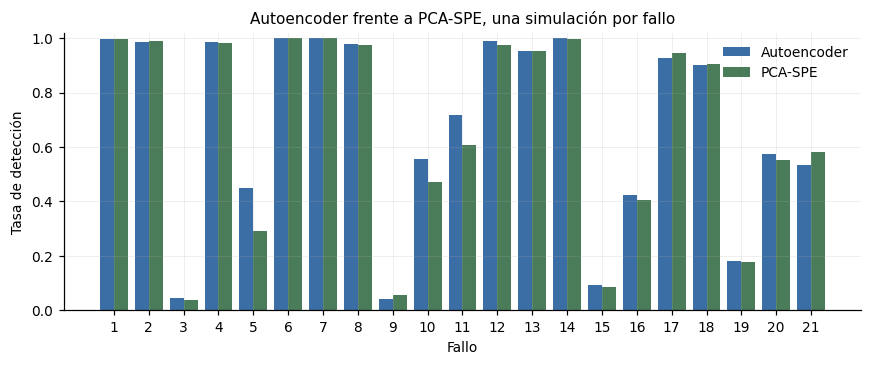

In [5]:
pca = PCAMonitor(variance=0.85, alpha=0.99).fit(X_fit, X_cal=X_cal)

filas = []
for fault in range(22):
    df = data.load_classic(fault, "test")
    X = data.values(df)
    onset_f = None if fault == 0 else onset

    e = error_reconstruccion(ae, escalador.transform(X))
    filas.append({"method": "Autoencoder", "faultNumber": fault, "simulationRun": 1,
                  **metrics.evaluate_run(e, umbral, onset_f)})

    _, spe = pca.score(X)
    filas.append({"method": "PCA-SPE", "faultNumber": fault, "simulationRun": 1,
                  **metrics.evaluate_run(spe, pca.spe_limit_, onset_f)})

res = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(8, 3.4))
for i, (nombre, g) in enumerate(res[res.faultNumber > 0].groupby("method")):
    ax.bar(g.faultNumber + (i - 0.5) * 0.4, g.fdr, width=0.4, label=nombre,
           color=[plots.COLORS["normal"], plots.COLORS["alt1"]][i])
ax.set_xticks(range(1, 22)); ax.set_xlabel("Fallo"); ax.set_ylabel("Tasa de detección")
ax.set_ylim(0, 1.02); ax.legend(); ax.set_title("Autoencoder frente a PCA-SPE, una simulación por fallo")
plt.tight_layout()

comp = res.pivot(index="faultNumber", columns="method", values=["far", "fdr", "delay_samples"]).round(3)
comp.loc[[0, 1, 3, 9, 15, 6]]

Las filas 3, 9 y 15 vuelven a ser el sitio interesante. Ahí es donde un método más potente podría marcar la diferencia, o no. Con una sola simulación no se puede afirmar nada; con las quinientas de Rieth y un contraste de Wilcoxon de `stats.py`, sí.

## 5. La trampa: qué pasa si el umbral se calibra mal

Esta sección es la razón de ser del bloque. Buena parte de la literatura de *deep learning* sobre el TEP reporta cifras de detección por encima del 99 %, y con frecuencia esas cifras vienen de uno de estos dos errores:

1. Calibrar el umbral con los mismos datos con los que se entrenó la red.
2. Elegir el umbral mirando los datos de prueba, por ejemplo tomando el que maximiza el F1 sobre el conjunto de prueba.

El primero infla las falsas alarmas. El segundo es fuga de datos en estado puro y hace que el resultado no signifique nada, porque el modelo ha visto la respuesta antes de examinarse. Aquí reproducimos el primero con números.

In [6]:
umbral_mal = limits.limit_empirical(error_reconstruccion(ae, Z_fit), alpha=0.99)   # calibrado en el ajuste

def far_media(umb):
    fars = []
    for f in range(1, 22):
        e = error_reconstruccion(ae, escalador.transform(data.values(data.load_classic(f, "test"))))
        fars.append(metrics.far(e[:onset], umb))
    return np.mean(fars)

print(f"Umbral calibrado en el AJUSTE  : {umbral_mal:6.2f}  →  FAR medio = {far_media(umbral_mal):.3f}")
print(f"Umbral calibrado con RESERVA   : {umbral:6.2f}  →  FAR medio = {far_media(umbral):.3f}")

Umbral calibrado en el AJUSTE  :  31.06  →  FAR medio = 0.177
Umbral calibrado con RESERVA   :  41.31  →  FAR medio = 0.028


Mismo modelo, mismos datos, misma confianza. La única diferencia es de dónde sale el umbral, y la tasa de falsas alarmas cambia varias veces. Un umbral que salta continuamente sobre datos sanos es inútil en planta aunque su tasa de detección sea perfecta.

Esta es la razón por la que el paquete tiene el parámetro `X_cal` y por la que `limit_empirical` se aplica siempre a datos reservados. Y es lo que hay que buscar cuando un artículo reporta un 99 % y no explica de dónde sacó el umbral.

La versión con PyTorch de todo esto es la misma en cada paso: entrenar con `Z_fit`, calibrar con `Z_cal` usando `limits.limit_empirical` o `limits.limit_kde`, y medir con `metrics.evaluate_run`. Lo único que cambia es cómo se construye la red.

## 6. Lo que viene después

Tres cosas, en este orden:

**Reescribir el autoencoder en PyTorch**, con varias capas y regularización, y comprobar que sobre estos mismos datos da un resultado parecido al de arriba. Si sale mucho mejor, lo primero es sospechar y revisar la calibración, no celebrar.

**Pasar a diagnóstico con LSTM y CNN 1D** sobre ventanas temporales. Ahí el conjunto etiquetado se monta como en `02_arranque_diagnostico`, y la métrica pasa a ser F1 por clase y macro-F1.

**Escalar a Rieth** con `data.load_rieth`, primero con 20 simulaciones y al final con 100 o más, para que `metrics.aggregate` dé intervalos de confianza y `stats.compare_methods` diga si las diferencias con el PCA y con los clasificadores de Jonathan son reales.

## Dónde está cada cosa

| Lo que hicimos | Módulo | Función |
|---|---|---|
| Cargar | `data.py` | `load_classic`, `values`, `FAULT_ONSET_TEST` |
| Estandarizar sin fuga | `preprocessing.py` | `Scaler` |
| Umbral con datos reservados | `limits.py` | `limit_empirical`, `limit_kde` |
| FAR, FDR, retardo | `metrics.py` | `evaluate_run`, `far` |
| Comparar con la línea base | `pca.py` | `PCAMonitor` |
| Figuras | `plots.py` | `control_chart`, `COLORS` |
| La red | scikit-learn (aquí) / PyTorch (después) | `MLPRegressor` |